# Necessary Library

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import csv
from math import sqrt, atan2, degrees
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib
from scipy.signal import butter,filtfilt

## Data set

In [ ]:
dataset_csv = "/content/train.csv"

# Given the number of columns per row is irregular, the number of columns of the
# biggest row is used as the header.
max_columns = ['Subject', 'Known'] + list(range(2, 44026))

# Read data set using Pandas' read_csv function
data = pd.read_csv(dataset_csv, names=max_columns, engine='python')
data.head()

,Subject,Known,2,3,4,5,6,7,8,9,...,44016,44017,44018,44019,44020,44021,44022,44023,44024,44025
0,s26,False,-739.34,1223.31,-739.85,1228.46,-740.35,1228.46,-740.35,1228.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s32,True,-12.31,202.49,-12.31,202.49,-11.96,202.49,-11.96,203.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s8,False,-664.47,-806.21,-665.24,-807.56,-666.01,-808.91,-666.40,-806.21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s7,False,-44.01,67.51,-44.42,68.40,-44.83,67.51,-44.01,66.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,True,636.58,-105.04,636.58,-103.52,635.56,-103.52,634.54,-103.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# I-VT Algorithm Implementation

In [ ]:

def I_VT_alg(points, sample_rate, up_sacc_thrs, sacc_thrs, fix_thrs, filt=True):
    # points: Eye tracking data points in the form of (x_values, y_values).
    # sample_rate: Sample rate for calculating the velocities.
    # sacc_thrs: Velocity threshold in pixels for a point to be considered a saccade.
    # fix_thrs: Velocity threshold in pixels for a point to be considered a fixation.
    # filt: When true, the velocity data is passed through a low pass filter

    saccades = []
    fixations = []
    fix_group = []
    saccade_group = []
    x_data = points[0]
    y_data = points[1]

    vels = []
    x_data = points[0]
    y_data = points[1]

    for i in range(len(x_data) - 1):
      # Velocity (sqrt((x2-x1)^2+(y2-y1)^2)/time), with 1/time = sample rate
        vels.append(
            sqrt(((x_data[i + 1] - x_data[i]) ** 2 + (y_data[i + 1] - y_data[i]) ** 2))
            * sample_rate
        )

    if filt:
      cutoff=1.2
      fs=30
      order=2
      nyq = 0.5 * fs  # Nyquist Frequency
      normal_cutoff = cutoff / nyq
      # Get the filter coefficients
      b, a = butter(order, normal_cutoff, btype='low', analog=False)
      vels = filtfilt(b, a, vels)

    # Saccades and fixations calculation
    for i in range(len(vels)):
        if (vels[i] >= sacc_thrs and vels[i] <= up_sacc_thrs):
            if fix_group:
                fixations.append(fix_group.copy())
                fix_group.clear()
            saccade_group.append([x_data[i], y_data[i]])

        elif vels[i] <= fix_thrs:
            if saccade_group:
              saccades.append(saccade_group.copy())
              saccade_group.clear()
            fix_group.append([x_data[i], y_data[i]])

    if fix_group:
        fixations.append(fix_group)
    if saccade_group:
        saccades.append(saccade_group)
    # Centroids calculation
    centroids = []
    centroids_count = []

    for group in fixations:
        group = np.array(group)
        group = group.T
        centroids.append([group[0].mean(), group[1].mean()])
        centroids_count.append(len(group[0]))
    return (saccades, fixations, centroids, centroids_count)

    # Returns:
    # saccades: A list with the points corresponding to saccades.
    # fixations: A list with the groups of points corresponding to fixation groups.
    # centroids: A list with the centroids of each fixation group.
    # centroids_count: A list with the number of points correspondent to each centroid.


# Methods for Plotting

In [ ]:
matplotlib.rcParams['figure.figsize'] = [18, 9]

def plot_gaze(gaze_data):
    # gaze_data: gaze data in (x_vals, y_vals) format
    x_data = gaze_data[0]
    y_data = gaze_data[1]
    plt.title("Gaze data", fontsize=20)
    plt.xlabel("Position X", fontsize=14)
    plt.ylabel("Position Y", fontsize=14)
    plt.scatter(x_data, y_data, s=5, color='b')
    plt.show()

def plot_simple(saccades, fixations, centroids):
    flat_fix = [point for fix_group in fixations for point in fix_group]
    flat_saccade = [point for saccade_group in saccades for point in saccade_group]
    fixX, fixY = np.array(flat_fix).T
    saccX, saccY = np.array(flat_saccade).T
    centX, centY = np.array(centroids).T
    plt.title("Saccades, fixations and centroids", fontsize=20)
    plt.xlabel("Position X", fontsize=14)
    plt.ylabel("Position Y", fontsize=14)
    plt.scatter(saccX, saccY, s=5, color="b", label="Saccades")
    plt.scatter(fixX, fixY, s=5, color="g", label="Fixations")
    plt.scatter(centX, centY, s=300, color="magenta", alpha=0.7, label="Centroids")
    plt.legend(borderpad=1)
    plt.axis('equal')
    plt.show()

def plot_centroids(centroids, centroids_count):
    fig, ax = plt.subplots()
    x, y = np.array(centroids).T
    # Draw fixation circles
    size = max(centroids_count)/50
    for i in range(len(centroids)):
      ax.add_artist(plt.Circle((x[i], y[i]), centroids_count[i]/size, color='magenta'))
    # Draw saccade lines
    for i in range(1, len(centroids)):
      plt.plot(x[i-1:i+1], y[i-1:i+1], 'b-')
    plt.title("Centroids", fontsize=20)
    plt.xlabel("Position X", fontsize=14)
    plt.ylabel("Position Y", fontsize=14)
    plt.axis('equal')
    plt.show()

def plot_vels(vels, sacc_thrs=None, fix_thrs=None):

    plt.plot(vels, label='Velocities')
    if sacc_thrs:
        plt.hlines(sacc_thrs, 0, len(vels), colors='r', linestyles='dashed', label='Saccaade threshold')
    if fix_thrs:
        plt.hlines(fix_thrs, 0,  len(vels), colors='r', linestyles='dashdot', label='Fixation threshold')
    plt.xlim(0, len(vels))
    plt.title("Velocity between points", fontsize=20)
    plt.xlabel("Point number (n)", fontsize=14)
    plt.ylabel("Point to point velocity (u/sec)", fontsize=14)
    plt.legend()
    plt.show()

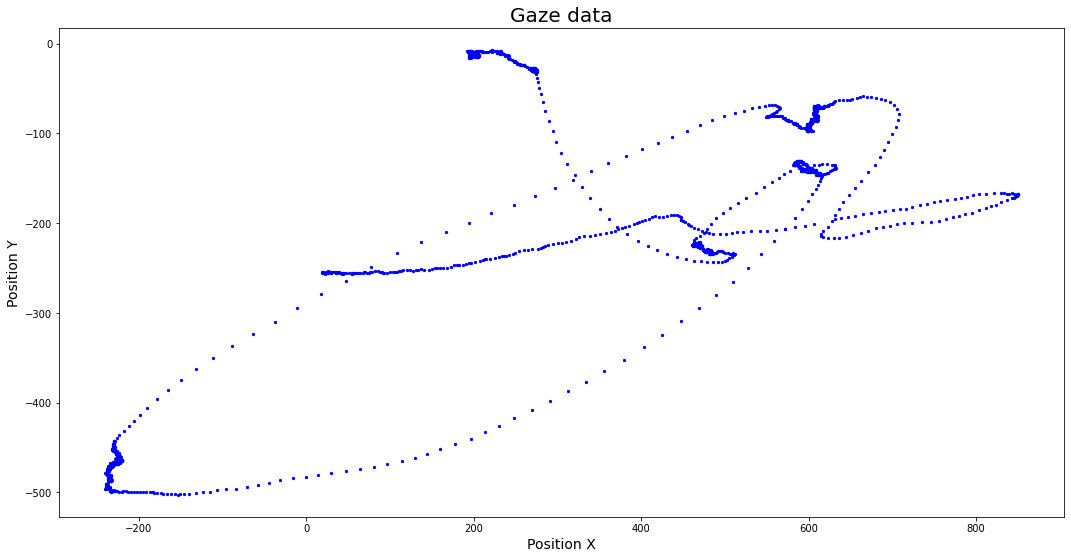

In [ ]:
# Extract row and remove NaN values at the tail
row = 1
series = data.iloc[row].dropna()
x_data = series[3::2]
y_data = series[2::2]

plot_gaze((x_data, y_data))

# Data set filetring

In [ ]:
# List with subjects of interest (My group subject for this assignment)
subjects = ["s2", "s4", "s10", "s17", "s18", "s24", "s30", "s32"]

subj_data = data[data.Subject.isin(subjects)]
# Group data by subjects
subj_data = subj_data.groupby(subj_data.Subject)
subj = subj_data.get_group("s4").reset_index(drop=True)
subj.head()

,Subject,Known,2,3,4,5,6,7,8,9,...,44016,44017,44018,44019,44020,44021,44022,44023,44024,44025
0,s4,False,735.38,276.22,734.64,274.54,735.38,274.54,736.86,274.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s4,False,-720.48,436.19,-719.51,437.86,-720.00,436.19,-721.46,432.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s4,True,730.56,1276.38,730.56,1276.38,731.05,1278.05,731.54,1276.38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,False,621.94,666.09,623.42,669.45,626.38,674.49,627.87,676.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s4,True,-705.42,-670.29,-703.94,-671.97,-703.94,-671.97,-704.68,-671.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Configuration 1

In [ ]:
sample_rate = 1000
thr_fix_deg = 50  # Fixation threshold in (degrees/s)
thr_fix_dur = 75 # fixation duration lower threshold (millisec)
thr_sacc_deg = 130  # Saccade threshold (degrees/s)
upper_thr_sacc_deg = 750 # Upper saccade threshold (degrees/s)
subj_dist = 45 # (cm)
vert_res = 768 # (cm)
monitor_dims = (19.5, 11.3) # (horizontal, vertical) (cm)

# Calculating saccades, fixations and centroids for **Configuration 1** and random subject **s4**

---



In [ ]:
#random subject
subj = subj_data.get_group("s4").reset_index(drop=True)
#random record
subj_record = subj.iloc[2].dropna()
x_data = list(subj_record[2::2]) # Even elements are x values
y_data = list(subj_record[3::2]) # Odd elements are y values

def pix_from_deg(h, d, res, size_in_deg, verbose=False):
    deg_per_px = degrees(atan2(.5*h, d)) / (.5*res)
    size_in_px = size_in_deg / deg_per_px
    return size_in_px

thr_sacc_px = pix_from_deg(monitor_dims[1], subj_dist, vert_res, thr_sacc_deg) # Saccade threshold in pixels

upper_thr_sacc_px = pix_from_deg(monitor_dims[1], subj_dist, vert_res, upper_thr_sacc_deg) # Upper saccade threshold in pixels

thr_fix_px = pix_from_deg(monitor_dims[1], subj_dist, vert_res, thr_fix_deg) # Fixation threshold in pixels

x_data = [(elem*monitor_dims[0])/monitor_dims[1] for elem in x_data] # Scale horizontal units to vertical units


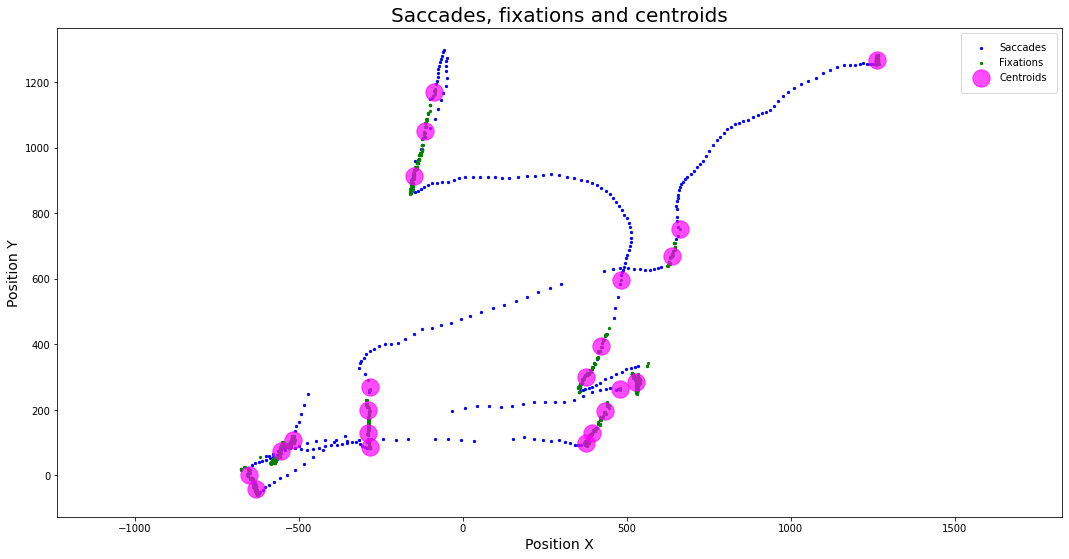

In [ ]:
# Calculate the saccades, fixations and centroids of record using I-VT algorithm
saccades, fixations, centroids, centroid_count = I_VT_alg((x_data, y_data), sample_rate, upper_thr_sacc_px, thr_sacc_px, thr_fix_px, filt=False)

plot_simple(saccades, fixations, centroids)


# Filtered Velocity Data

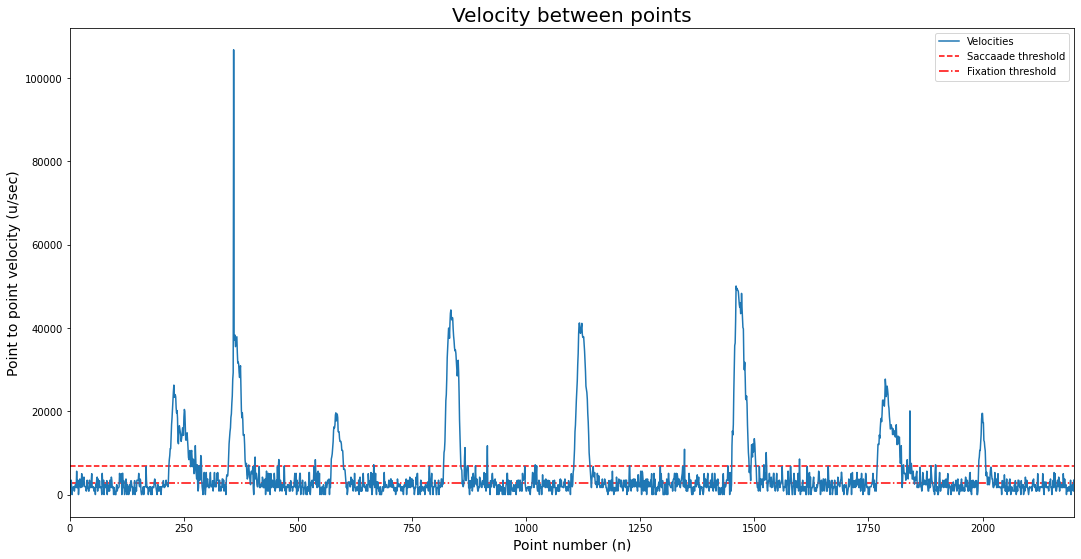

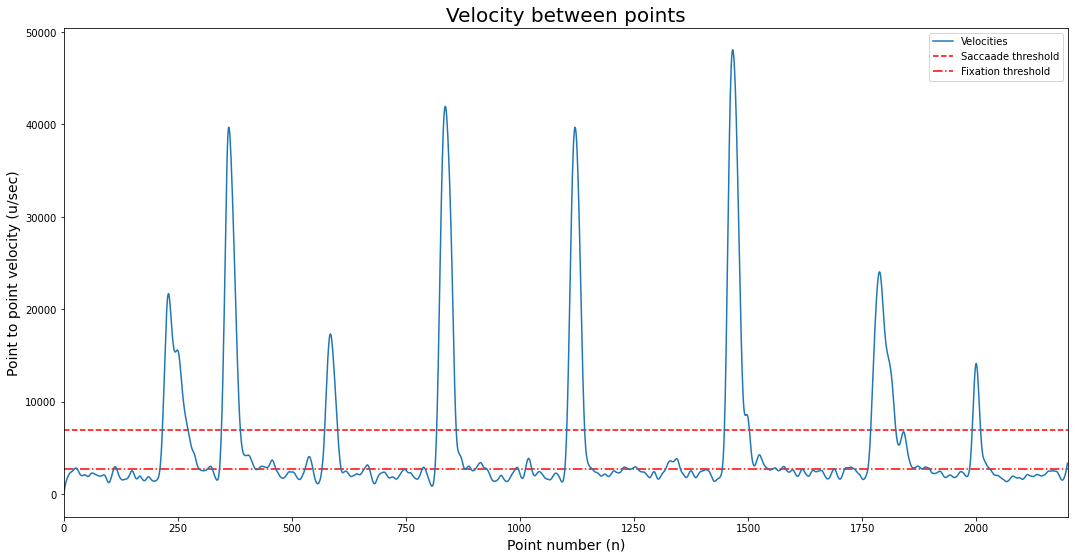

In [ ]:
vels = [] # List to store velocities
for i in range(len(x_data) - 1):
    vels.append(
        sqrt(((x_data[i + 1] - x_data[i]) ** 2 + (y_data[i + 1] - y_data[i]) ** 2))
        * sample_rate
    )

cutoff=1.2
fs=30
order=2
nyq = 0.5 * fs  # Nyquist Frequency
normal_cutoff = cutoff / nyq
# Get the filter coefficients
b, a = butter(order, normal_cutoff, btype='low', analog=False)
filt_vels = filtfilt(b, a, vels)

plot_vels(vels, thr_sacc_px, thr_fix_px)
plot_vels(filt_vels, thr_sacc_px, thr_fix_px)


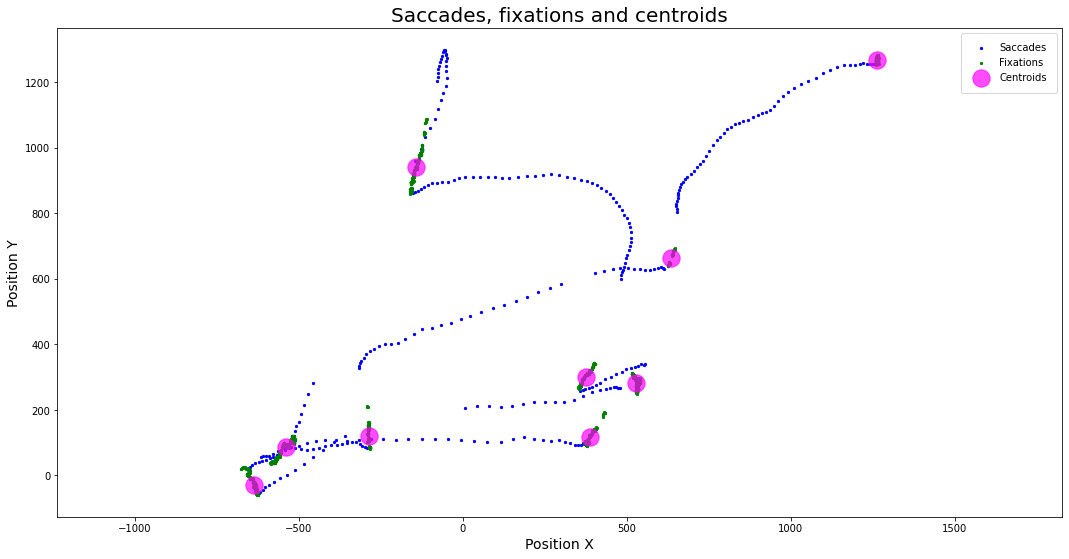

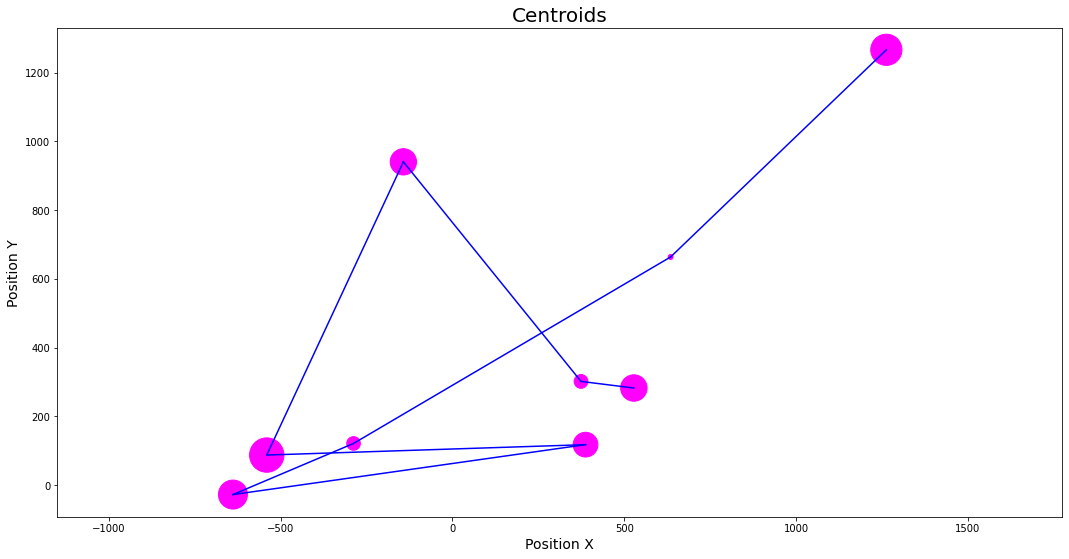

In [ ]:
saccades, fixations, centroids, centroid_count = I_VT_alg((x_data, y_data),
                                         sample_rate,
                                         upper_thr_sacc_px,
                                         thr_sacc_px,
                                         thr_fix_px,
                                         filt=True)

plot_simple(saccades, fixations, centroids)
plot_centroids(centroids, centroid_count)

# Configuration 2

In [ ]:
sample_rate2 = 1000
thr_fix_deg2 = 52  # Fixation threshold in (degrees/s)
thr_fix_dur2 = 71 # fixation duration lower threshold (millisec)
thr_sacc_deg2 = 140  # Saccade threshold (degrees/s)
upper_thr_sacc_deg2 = 760 # Upper saccade threshold (degrees/s)
subj_dist2 = 48 # (cm)
vert_res2 = 765 # (cm)
monitor_dims2 = (18.2, 12.1) # (horizontal, vertical) (cm)

# Calculating saccades, fixations and centroids for **Configuration 2** and random subject **s4**


In [ ]:
#random subject
subj2 = subj_data.get_group("s4").reset_index(drop=True)
#random record
subj_record2 = subj2.iloc[2].dropna()
x_data2 = list(subj_record[2::2]) # Even elements are x values
y_data2 = list(subj_record[3::2]) # Odd elements are y values


thr_sacc_px2 = pix_from_deg(monitor_dims2[1], subj_dist2, vert_res2, thr_sacc_deg2) # Saccade threshold in pixels

upper_thr_sacc_px2 = pix_from_deg(monitor_dims2[1], subj_dist2, vert_res2, upper_thr_sacc_deg2) # Upper saccade threshold in pixels

thr_fix_px2 = pix_from_deg(monitor_dims2[1], subj_dist2, vert_res2, thr_fix_deg2) # Fixation threshold in pixels

x_data2 = [(elem*monitor_dims2[0])/monitor_dims2[1] for elem in x_data2] # Scale horizontal units to vertical units


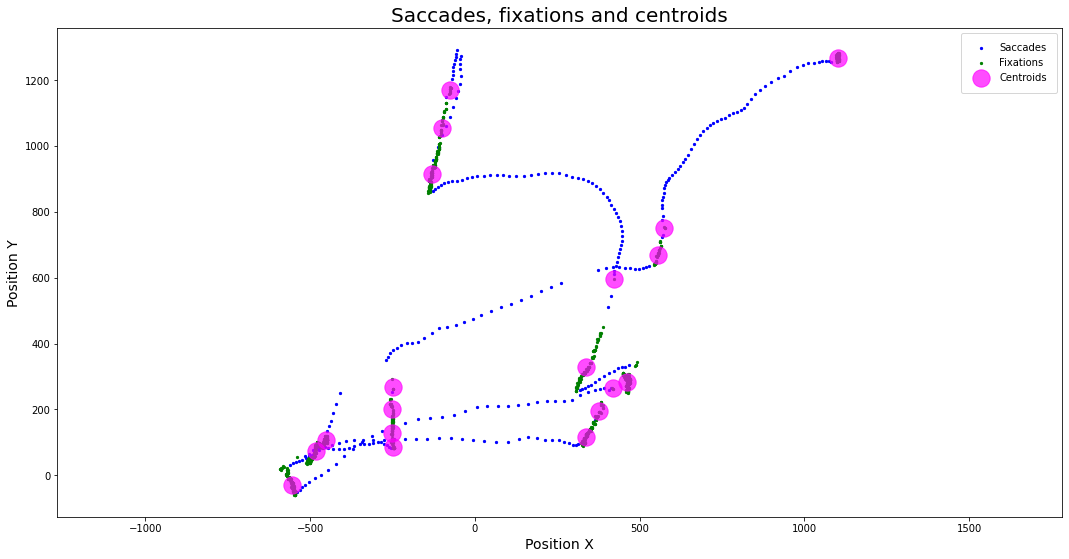

In [ ]:
# Calculate the saccades, fixations and centroids of record using I-VT algorithm
saccades, fixations, centroids, centroid_count = I_VT_alg((x_data2, y_data2), sample_rate2, upper_thr_sacc_px2, thr_sacc_px2, thr_fix_px2, filt=False)

plot_simple(saccades, fixations, centroids)

# Interactive

In [ ]:
from ipywidgets import interact, interact_manual


@interact
def get_subj(Subject=subjects):
    subj_recs = subj_data.get_group(Subject).reset_index(drop=True)
    recs = range(len(subj_recs.index))
    @interact
    def get_rec(Record=recs):
        # print(subj_recs)
        record = subj_recs.iloc[Record].dropna()
        x_data = list(record[2::2]) # Even elements are x values
        y_data = list(record[3::2]) # Odd elements are y values
        x_data = [(elem*monitor_dims[0])/monitor_dims[1] for elem in x_data]
        @interact
        def get_I_VT(Saccade_Threshold=(100, 600, 10),
                      Fixation_Threshold=(100, 300, 10),
                      Filter=True):
            # Saccade threshold in pixels
            thr_sacc_px = pix_from_deg(
                monitor_dims[1], subj_dist, vert_res, Saccade_Threshold
            )
            # Fixation threshold in pixels
            thr_fix_px = pix_from_deg(
                monitor_dims[1], subj_dist, vert_res, Fixation_Threshold
            )
            saccades, fixations, centroids, centroid_count = I_VT_alg((x_data, y_data), sample_rate, upper_thr_sacc_px, thr_sacc_px, thr_fix_px, filt=Filter)
            @interact
            def select_plot(Plot=["Data",
                                "Fixations",
                                "Centroids"]):
                if Plot == "Data":
                    plot_gaze((x_data, y_data))
                elif Plot == "Fixations":
                    plot_simple(saccades, fixations, centroids)
                elif Plot == "Centroids":
                    plot_centroids(centroids, centroid_count)
                return
            return
    return

interactive(children=(Dropdown(description='Subject', options=('s2', 's4', 's10', 's17', 's18', 's24', 's30', …

# Data Analysis

In [ ]:
subjects = ["s2", "s4", "s10", "s17", "s18", "s24", "s30", "s32"]

subjs_data_ivt = {}

fix_true_overall_ivt = []
fix_false_overall_ivt = []

sac_true_overall_ivt = []
sac_false_overall_ivt = []



for subject in subjects:
  # Get records from current subject
  subj = subj_data.get_group(subject).reset_index(drop=True)

  fix_true_ivt = []
  fix_false_ivt = []
  sacc_true_ivt = []
  sacc_false_ivt = []

  for session in range(len(subj)):

    # Get random record from subject
    subj_record = subj.iloc[session].dropna()

    # Extract X and Y values from record points
    x_data = list(subj_record[2::2]) # Even elements are x values
    y_data = list(subj_record[3::2]) # Odd elements are y values

    thr_sacc_px = pix_from_deg(
        monitor_dims[1], subj_dist, vert_res, thr_sacc_deg
    )

    thr_fix_px = pix_from_deg(
        monitor_dims[1], subj_dist, vert_res, thr_fix_deg
    )

    x_data = [(elem*monitor_dims[0])/monitor_dims[1] for elem in x_data]

    saccades_ivt, fixations_ivt, _, _ = I_VT_alg((x_data, y_data), sample_rate, upper_thr_sacc_px, thr_sacc_px, thr_fix_px, True)

    for fix_gr in fixations_ivt:
      duration = len(fix_gr)/sample_rate * 1000
      if duration >= thr_fix_dur:
        if (subj_record.Known):
          fix_true_ivt.append(duration)
          fix_true_overall_ivt.append(duration)

        else:
          fix_false_ivt.append(duration)
          fix_false_overall_ivt.append(duration)

    for sacc_gr in saccades_ivt:
      deg_per_px = degrees(atan2(.5*monitor_dims[1], subj_dist)) / (.5*vert_res)
      amplitude  = sqrt(((sacc_gr[-1][0] - sacc_gr[0][0]) ** 2 + (sacc_gr[-1][1] - sacc_gr[0][1]) ** 2)) * deg_per_px

      if (subj_record.Known):
        sacc_true_ivt.append(amplitude)
        sac_true_overall_ivt.append(amplitude)

      else:
        sacc_false_ivt.append(amplitude)
        sac_false_overall_ivt.append(amplitude)

  # Calculate mean fixation duration and standard deviation for current subject
  # separating known = true from false for I-VT
  mfd_true_ivt = np.mean(fix_true_ivt)
  mfd_sd_true_ivt = np.std(fix_true_ivt)
  mfd_false_ivt = np.mean(fix_false_ivt)
  mfd_sd_false_ivt = np.std(fix_false_ivt)

  # Calculate mean saccade amplitude and standard deviation for current subject
  # separating known = true from false for I-DT
  msa_true_ivt = np.mean(sacc_true_ivt)
  msa_sd_true_ivt = np.std(sacc_true_ivt)
  msa_false_ivt = np.mean(sacc_false_ivt)
  msa_sd_false_ivt = np.std(sacc_false_ivt)


  # Store I-VT values in dictionary
  subjs_data_ivt[subject] = {'mfd_true': mfd_true_ivt,
                         'mfd_sd_true' : mfd_sd_true_ivt,
                         'mfd_false' : mfd_false_ivt,
                         'mfd_sd_false' : mfd_sd_false_ivt,
                         'msa_true': msa_true_ivt,
                         'msa_sd_true' : msa_sd_true_ivt,
                         'msa_false' : msa_false_ivt,
                         'msa_sd_false' : msa_sd_false_ivt}

# Calculate the aggregated mean fixation duration
# for known true and false for all subjects using I-VT
mfd_overall_true_ivt = np.mean(fix_true_overall_ivt)
mfd_overall_false_ivt = np.mean(fix_false_overall_ivt)

mfd_overall_true_SD_ivt = np.std(fix_true_overall_ivt)
mfd_overall_false_SD_ivt = np.std(fix_false_overall_ivt)


# Calculate the aggregated mean saccade amplitude
# for known true and false for all subjects using I-VT
msa_overall_true_ivt = np.mean(sac_true_overall_ivt)
msa_overall_false_ivt = np.mean(sac_false_overall_ivt)

msa_overall_true_SD_ivt = np.std(sac_true_overall_ivt)
msa_overall_false_SD_ivt = np.std(sac_false_overall_ivt)


mfd_true_ivt = []
mfd_sd_true_ivt = []
mfd_false_ivt =[]
mfd_sd_false_ivt = []
msa_true_ivt = []
msa_sd_true_ivt = []
msa_false_ivt = []
msa_sd_false_ivt = []

for subj in subjs_data_ivt:
    mfd_true_ivt.append(subjs_data_ivt[subj]['mfd_true'])
    mfd_false_ivt.append(subjs_data_ivt[subj]['mfd_false'])
    msa_true_ivt.append(subjs_data_ivt[subj]['msa_true'])
    msa_false_ivt.append(subjs_data_ivt[subj]['msa_false'])
    mfd_sd_true_ivt.append(subjs_data_ivt[subj]['mfd_sd_true'])
    mfd_sd_false_ivt.append(subjs_data_ivt[subj]['mfd_sd_false'])
    msa_sd_true_ivt.append(subjs_data_ivt[subj]['msa_sd_true'])
    msa_sd_false_ivt.append(subjs_data_ivt[subj]['msa_sd_false'])

# Creating csv file

Creating csv file with the following structure and header, named according to our group, and fill in the resulting data for all subject ids assigned to our group:


---


*subject_id, MFD_true, MFD_SD_true, MFD_false, MFD_SD_false, MSA_true, MSA_SD_true, MSA_false, MSA_SD_false, MFD_overall, MFD_overall_SD, MSA_overall, MSA_overall_SD*

In [ ]:
with open('/content/ET_group_2.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["subject_id", "MFD_true", "MFD_SD_true", "MFD_false",
                     "MFD_SD_false", "MSA_true", "MSA_SD_true", "MSA_false",
                     "MSA_SD_false", "MFD_overall", "MFD_overall_SD",
                     "MSA_overall", "MSA_overall_SD"])
    for subj in subjs_data_ivt:
      row = [subj, subjs_data_ivt[subj]['mfd_true'], subjs_data_ivt[subj]['mfd_sd_true'],
            subjs_data_ivt[subj]['mfd_false'], subjs_data_ivt[subj]['mfd_sd_false'],
            subjs_data_ivt[subj]['msa_true'], subjs_data_ivt[subj]['msa_sd_true'],
            subjs_data_ivt[subj]['msa_false'], subjs_data_ivt[subj]['msa_sd_false'],
            mfd_overall_true_ivt, mfd_overall_true_SD_ivt, msa_overall_true_ivt, msa_overall_true_SD_ivt]
      writer.writerow([item for item in row])


# Data Plot

<Figure size 1296x648 with 0 Axes>

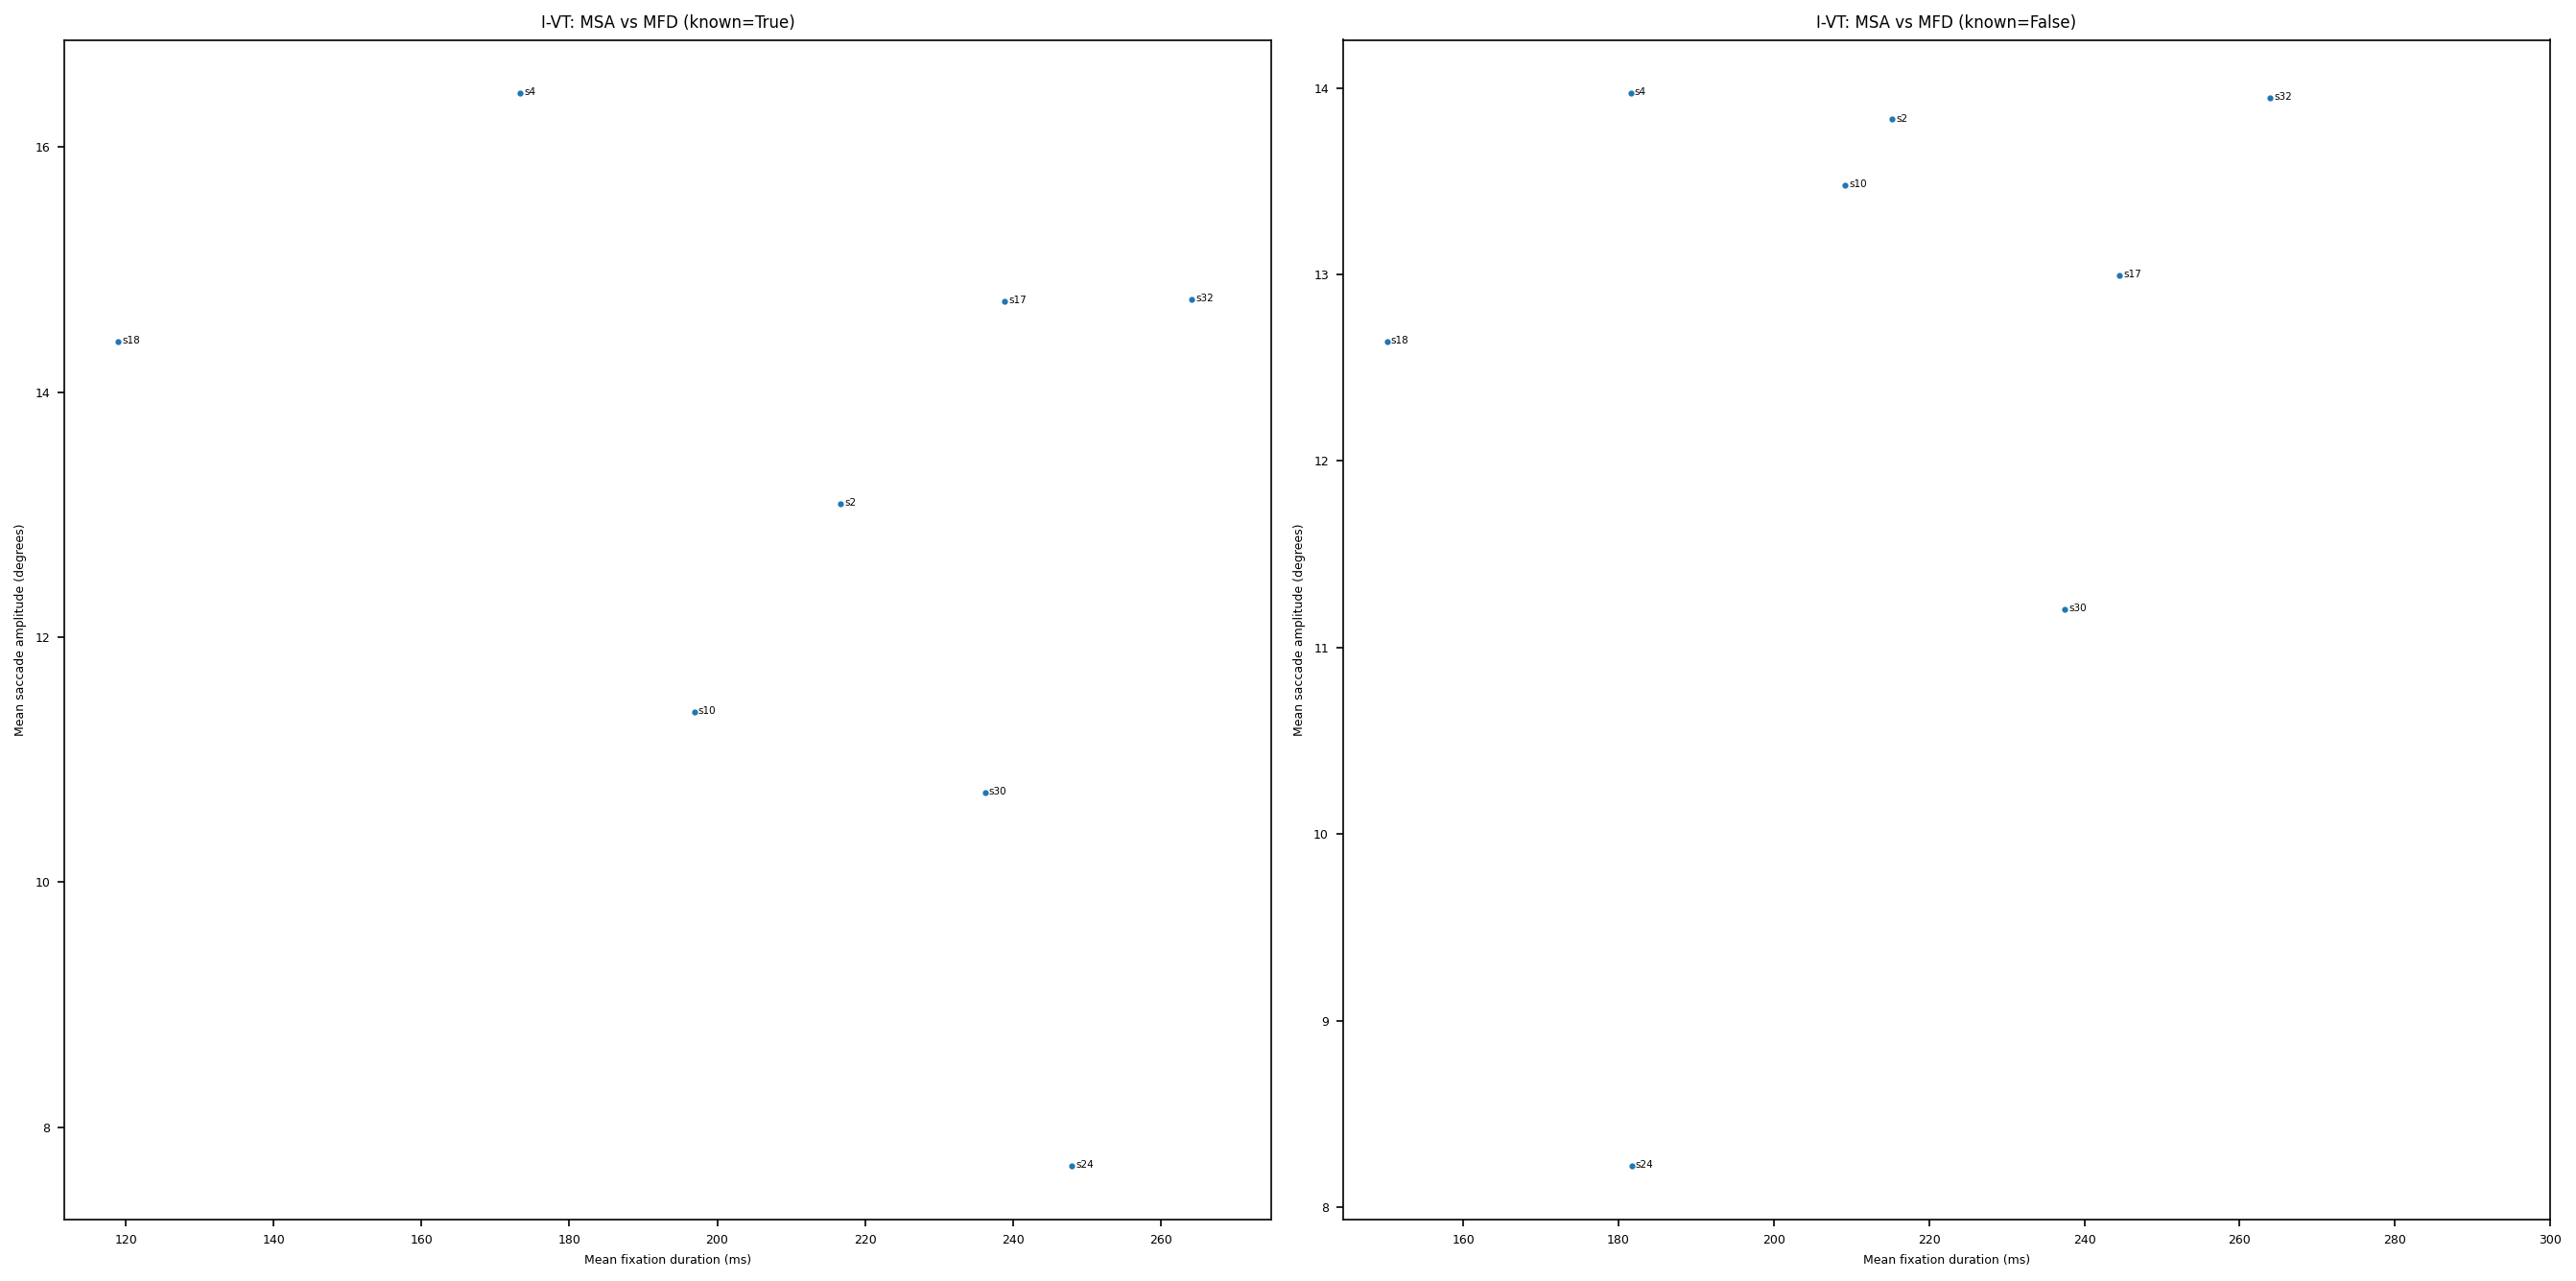

In [ ]:
mfd_true_ivt = []
mfd_sd_true_ivt = []
mfd_false_ivt =[]
mfd_sd_false_ivt = []
msa_true_ivt = []
msa_sd_true_ivt = []
msa_false_ivt = []
msa_sd_false_ivt = []


for subj in subjs_data_ivt:
    mfd_true_ivt.append(subjs_data_ivt[subj]['mfd_true'])
    mfd_false_ivt.append(subjs_data_ivt[subj]['mfd_false'])
    msa_true_ivt.append(subjs_data_ivt[subj]['msa_true'])
    msa_false_ivt.append(subjs_data_ivt[subj]['msa_false'])
    mfd_sd_true_ivt.append(subjs_data_ivt[subj]['mfd_sd_true'])
    mfd_sd_false_ivt.append(subjs_data_ivt[subj]['mfd_sd_false'])
    msa_sd_true_ivt.append(subjs_data_ivt[subj]['msa_sd_true'])
    msa_sd_false_ivt.append(subjs_data_ivt[subj]['msa_sd_false'])



fig = plt.figure()
plt.rcParams['figure.dpi'] = 150

fig, axes = plt.subplots(nrows = 1, ncols = 2)

axes[0].scatter(mfd_true_ivt, msa_true_ivt, s=4)
axes[0].set_xlabel('Mean fixation duration (ms)', fontsize=6)
axes[0].set_ylabel('Mean saccade amplitude (degrees)', fontsize=6)
axes[0].set_title('I-VT: MSA vs MFD (known=True)', fontsize=8)
axes[0].tick_params(axis="both", labelsize=6)
axes[0].set_xlim(xmax=275)
for idx, subject in enumerate(subjects):
    axes[0].annotate(subject, (mfd_true_ivt[idx], msa_true_ivt[idx]),
                        xytext=(2,-1), textcoords='offset points', fontsize=5)

axes[1].scatter(mfd_false_ivt, msa_false_ivt, s=4)
axes[1].set_xlabel('Mean fixation duration (ms)', fontsize=6)
axes[1].set_ylabel('Mean saccade amplitude (degrees)', fontsize=6)
axes[1].set_title('I-VT: MSA vs MFD (known=False)', fontsize=8)
axes[1].tick_params(axis="both", labelsize=6)
axes[1].set_xlim(xmax=300)
for idx, subject in enumerate(subjects):
    axes[1].annotate(subject, (mfd_false_ivt[idx], msa_false_ivt[idx]),
                        xytext=(2,-1), textcoords='offset points', fontsize=5)

fig.tight_layout()
fig.savefig('/content/msa_mfd.eps', format='eps')

In [ ]:
print('mfd_overall_true I-VT', round(mfd_overall_true_ivt, 2), ' +/- ', round(mfd_overall_true_SD_ivt, 2))
print('mfd_overall_false I-VT', round(mfd_overall_false_ivt, 2), ' +/- ', round(mfd_overall_false_SD_ivt, 2))
print('msa_overall_true I-VT', round(msa_overall_true_ivt, 2), ' +/- ', round(msa_overall_true_SD_ivt, 2))
print('msa_overall_false I-VT', round(msa_overall_false_ivt, 2), ' +/- ', round(msa_overall_false_SD_ivt, 2))

mfd_overall_true I-VT 213.73  +/-  104.82
mfd_overall_false I-VT 217.49  +/-  119.62
msa_overall_true I-VT 14.06  +/-  9.45
msa_overall_false I-VT 12.89  +/-  8.85


In [ ]:
print('I-VT: MFD true Vs false ', mannwhitneyu(mfd_true_ivt, mfd_false_ivt))
print('I-VT: MSA true Vs false ', mannwhitneyu(msa_true_ivt, msa_false_ivt))
print('I-VT true: MSA Vs MFD ', mannwhitneyu(msa_true_ivt/np.linalg.norm(msa_true_ivt), mfd_true_ivt/np.linalg.norm(mfd_true_ivt)))
print('I-VT false: MSA Vs MFD ', mannwhitneyu(msa_false_ivt/np.linalg.norm(msa_false_ivt), mfd_false_ivt/np.linalg.norm(mfd_false_ivt)))

I-VT: MFD true Vs false  MannwhitneyuResult(statistic=35.0, pvalue=0.7984459984459983)
I-VT: MSA true Vs false  MannwhitneyuResult(statistic=39.0, pvalue=0.5053613053613053)
I-VT true: MSA Vs MFD  MannwhitneyuResult(statistic=33.0, pvalue=0.959129759129759)
I-VT false: MSA Vs MFD  MannwhitneyuResult(statistic=32.0, pvalue=1.0)
